In [1]:
# Importing necessary libraries for data preprocessing
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Importing necessary libraries for building and evaluating models
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.losses import KLDivergence, MeanSquaredError

# Importing necessary libraries for saving and loading models
import joblib

In [2]:
df = pd.read_csv('KDDTrain+.txt', header=None)

In [3]:
pd.set_option('display.max_columns',None)

In [4]:
# Converting into binary classification
df[41] = (df[41] != 'normal') * 1

In [5]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [6]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove(42)  # removing additional info column

In [7]:
# Define preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)])

In [8]:
# Applying ColumnTransformer
df_processed = preprocessor.fit_transform(df.drop(columns=[41, 42]))
df_processed = pd.DataFrame(df_processed)

In [9]:
# Convert the target column to numeric
le = LabelEncoder()
df[41] = le.fit_transform(df[41])

In [10]:
# Extract target variable
y = df[41].values

In [11]:
# Check shape of preprocessed data
df_processed.shape, y.shape

((125973, 122), (125973,))

In [12]:
# Set random seed for reproducibility 
np.random.seed(42)
tf.random.set_seed(42)

In [13]:
# Define the dimensionality of the bottleneck for each autoencoder
bottleneck_dims = [64, 32, 16, 8]

In [14]:
# Store the models and their encoders
autoencoders = []
encoders = []

In [15]:
weight_decay = 0.001
learning_rate = 0.005

In [16]:
# Define the sparsity parameter and target sparsity
sparsity_target = 0.05
sparsity_weight = 0.1

mse_loss = MeanSquaredError()
kl_loss = KLDivergence()

def custom_loss(y_true, y_pred):
    # Calculate the MSE loss
    mse = mse_loss(y_true, y_pred)

    # Calculate the average activation of the bottleneck layer
    avg_activation = K.mean(y_pred, axis=0)

    # Calculate the KL Divergence for the sparsity constraint
    kl = K.sum(sparsity_target * K.log(sparsity_target / avg_activation) +
               (1 - sparsity_target) * K.log((1 - sparsity_target) / (1 - avg_activation)))

    # Combine the MSE and KL Divergence losses
    return mse + sparsity_weight * kl

In [17]:
def autoencoder_model(bottleneck_dims):
    autoencoder = Sequential([
        Dense(64, activation = 'relu', input_shape=(df_processed.shape[1],)),
        Dense(bottleneck_dims, activation = 'relu'),
        Dense(df_processed.shape[1], activation = 'sigmoid')
    ])
    
    return autoencoder

# Define and train the autoencoders
for i, bottleneck_dim in enumerate(bottleneck_dims):

    print(f"Training {i+1} autoencoder model")
    # Define the autoencoder
    autoencoder = autoencoder_model(bottleneck_dim)
    
    # Compile the autoencoder
    autoencoder.compile(optimizer = Adam(learning_rate = learning_rate, decay = weight_decay), loss = custom_loss)
    
    # Train the autoencoder
    history = autoencoder.fit(df_processed, df_processed, epochs = 10, batch_size = 256, verbose = 1)
    
    # Define the encoder
    encoder = Sequential(autoencoder.layers[:2])
    
    # Save the autoencoder and encoder
    autoencoders.append(autoencoder)
    encoders.append(encoder)
    
    # Update df_processed for the next autoencoder
    df_processed = encoder.predict(df_processed)
    print("\n")

Training 1 autoencoder model
Epoch 1/10
493/493 [==============================] - 5s 6ms/step - loss: 0.1492
Epoch 2/10
493/493 [==============================] - 3s 5ms/step - loss: 0.0517
Epoch 3/10
493/493 [==============================] - 3s 6ms/step - loss: 0.0490
Epoch 4/10
493/493 [==============================] - 2s 5ms/step - loss: 0.0480
Epoch 5/10
493/493 [==============================] - 3s 5ms/step - loss: 0.0472
Epoch 6/10
493/493 [==============================] - 3s 5ms/step - loss: 0.0468A: 0s - loss: - ETA: 0s - loss:
Epoch 7/10
493/493 [==============================] - 3s 6ms/step - loss: 0.0466A:
Epoch 8/10
493/493 [==============================] - 3s 6ms/step - loss: 0.0463
Epoch 9/10
493/493 [==============================] - 2s 5ms/step - loss: 0.0460
Epoch 10/10
493/493 [==============================] - 3s 5ms/step - loss: 0.0460


Training 2 autoencoder model
Epoch 1/10
493/493 [==============================] - 4s 4ms/step - loss: 1.2322
Epoch 2/10
493/

In [18]:
df_processed = pd.DataFrame(df_processed)
df_processed

,0,1,2,3,4,5,6,7
0,55.254429,36.657406,69.595222,0.000000,0.0,10.654841,10.108330,65.332504
1,41.887489,52.894001,121.511620,0.000000,0.0,0.000000,0.000000,81.214401
2,0.000000,9.993004,54.879795,0.000000,0.0,0.000000,3.055622,74.375397
3,17.201082,14.448551,5.481700,7.001506,0.0,30.224918,1.018067,21.944904
4,14.475527,15.928388,6.449054,15.596462,0.0,34.234077,0.000000,24.825779
...,...,...,...,...,...,...,...,...
125968,0.000000,10.138940,54.681404,0.000000,0.0,0.000000,2.984623,74.999580
125969,11.509863,29.088346,84.743553,18.196468,0.0,13.113575,0.000000,58.281494
125970,78.902054,52.664513,53.895462,0.000000,0.0,0.000000,1.513729,69.986794
125971,9.070845,12.941422,0.000000,0.000000,0.0,0.000000,4.317227,61.229816


In [19]:
# Now, df_processed is the output from the last encoder. We can use this to train our XGBoost model.
X_train, X_test, y_train, y_test = train_test_split(df_processed, y, test_size=0.2, random_state=42)

***

In [20]:
# Hyperparameter tuning for XGBoost Classifier using GridSearchCV
param_grid = {
    'max_depth': [6, 8, 10],
    'learning_rate': [0.1, 0.3],
    'n_estimators': [100, 200, 300],
    'subsample': [0.5, 0.8, 1.0]
}

param_grid

{'max_depth': [6, 8, 10],
 'learning_rate': [0.1, 0.3],
 'n_estimators': [100, 200, 300],
 'subsample': [0.5, 0.8, 1.0]}

In [21]:
# Intialize the XGBoost model 
xgboost = XGBClassifier(objective = 'binary:logistic',eval_metric = 'logloss')

# Perform grid search with cross-validation
xgboost_gridcv = GridSearchCV(estimator = xgboost ,param_grid = param_grid, cv=3, verbose=3, n_jobs = -1)

### fit the grid searched model
%time xgboost_gridcv.fit(X_train,y_train)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Wall time: 23min 21s


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                   

In [22]:
# save the model to a file
joblib.dump(xgboost_gridcv, 'xgboost_gridseach_binary.joblib')

['xgboost_gridseach_binary.joblib']

In [23]:
# print best parameter after tuning 
print(xgboost_gridcv.best_params_) 

# Get the best estimator
best_gridcv = xgboost_gridcv.best_estimator_

{'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.8}


****

In [24]:
# Prediction on test dataset
%time y_pred_test = best_gridcv.predict(X_test)

# printing the predictions
print(y_pred_test)

Wall time: 213 ms
[0 1 1 ... 0 0 1]


In [25]:
# Print the classification report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     13422
           1       0.99      0.99      0.99     11773

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195



In [26]:
#  Compute the AUC Score

xgboost_roc_score = roc_auc_score(y_test, y_pred_test)
xgboost_roc_score

0.9919986434894944

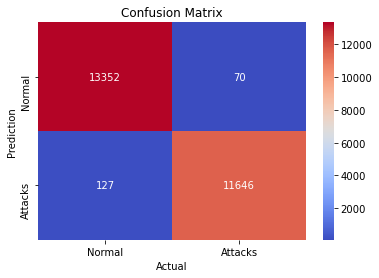

In [27]:
# Calculate Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Plot the confusion matrix
sns.heatmap(cm,
            annot = True, 
            fmt = "g", 
            cmap = 'coolwarm',
            yticklabels= ['Normal', 'Attacks'],
            xticklabels= ['Normal', 'Attacks'])

plt.title('Confusion Matrix')
plt.xlabel("Actual")
plt.ylabel("Prediction")
plt.show()

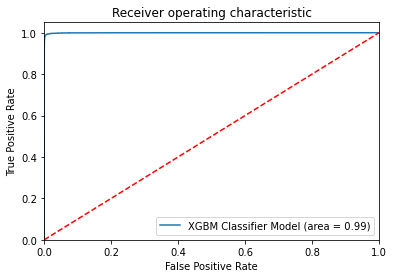

In [28]:
# Predict probabilities for the test data and Keep Probabilities of the positive class only
fpr, tpr, thresholds = roc_curve(y_test, best_gridcv.predict_proba(X_test)[:, 1]) 

# Plot the roc curve 
plt.plot(fpr, tpr, label='XGBM Classifier Model (area = %0.2f)' % xgboost_roc_score)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()   

****

In [29]:
# Predict the training time on train dataset
%time y_pred_train = best_gridcv.predict(X_train)

# printing the predictions
y_pred_train

Wall time: 400 ms


array([0, 1, 1, ..., 1, 0, 0])

In [30]:
# Print the classification report for training dataset 
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     53921
           1       1.00      1.00      1.00     46857

    accuracy                           1.00    100778
   macro avg       1.00      1.00      1.00    100778
weighted avg       1.00      1.00      1.00    100778



In [31]:
def metrics(y_train, y_pred_train, y_test, y_pred_test):
    precision_train = precision_score(y_train, y_pred_train)
    precision_test = precision_score(y_test, y_pred_test)
    recall_train = recall_score(y_train, y_pred_train)
    recall_test = recall_score(y_test, y_pred_test)
    f1score_train = f1_score(y_train, y_pred_train)
    f1score_test = f1_score(y_test, y_pred_test)
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    metrics_dict = {
        "Precision (Train)": precision_train,
        "Precision (Test)": precision_test,
        "Recall (Train)": recall_train,
        "Recall (Test)": recall_test,
        "F1 Score (Train)": f1score_train,
        "F1 Score (Test)": f1score_test,
        "Accuracy (Train)": accuracy_train,
        "Accuracy (Test)": accuracy_test,
    }
    
    return metrics_dict

metrics(y_train, y_pred_train, y_test, y_pred_test)

{'Precision (Train)': 0.9998292130993552,
 'Precision (Test)': 0.9940252645954251,
 'Recall (Train)': 0.9995091448449538,
 'Recall (Test)': 0.989212605113395,
 'F1 Score (Train)': 0.9996691533527572,
 'F1 Score (Test)': 0.9916130954915067,
 'Accuracy (Train)': 0.9996923931810514,
 'Accuracy (Test)': 0.9921809882913276}

****

In [22]:
# Checking for overfitting

%time print('Training set score: {:.4f}'.format(xgboost_gridcv.score(X_train, y_train)))

%time print('Test set score: {:.4f}'.format(xgboost_gridcv.score(X_test, y_test)))

Training set score: 0.9997
Wall time: 608 ms
Test set score: 0.9922
Wall time: 194 ms


***

In [23]:
# False Alarm Rate for test data 

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# calculate false positive and True negative values 
FP = cm[0, 1]  
TN = cm[0, 0]  

False_alarm_rate = FP / (FP + TN)

print(False_alarm_rate * 100)

0.5215318134406199


***